# K Nearest Neighbors

The k-Nearest Neighbors (KNN) classifier is a non-parametric, instance-based learning method that classifies observations based on the labels of their nearest neighbors in the feature space. Unlike parametric models, KNN does not estimate parameters during training; instead, it stores the training data and performs most computation at prediction time through distance calculations.

Because predictions rely on distance, **feature scaling is critical** for KNN. Variables with larger numeric ranges can dominate the distance metric if the data are not standardized. The same standardized features used in previous models are therefore retained.

The behavior of KNN is primarily controlled by three parameters: the number of neighbors (*k*), the distance metric, and the weighting of neighbors. Smaller values of *k* produce flexible decision boundaries with **higher variance**, while larger values smooth the boundary and increase bias. In this study, *k* is selected using cross-validation over a range from 1 to approximately the square root of the number of observations.

Distances are computed using the `'minkowski'` `metric`, where *p = 2* corresponds to the Euclidean distance (the default) and *p = 1* corresponds to the Manhattan distance. The `weights` parameter controls whether neighbors contribute equally (`uniform`) or whether closer observations have greater influence (`distance`).


In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score


example = KNeighborsClassifier(
    n_neighbors=5, # number of neighbors to use
    weights='uniform', # weight function used in prediction options are 'uniform' and 'distance'
    algorithm='auto', # used to compute the nearest neighbors, options are 'auto', 'ball_tree', 'kd_tree', 'brute'
    leaf_size=30, 
    p=2, # power parameter for the Minkowski metric, p=1 is equivalent to using manhattan_distance and p=2 is equivalent to using euclidean_distance
    metric='minkowski', # the distance metric to use for the tree, the default is minkowski and with p=2 is equivalent to the standard Euclidean metric
    metric_params=None, 
    n_jobs=None,
)

?KNeighborsClassifier

Init signature:
KNeighborsClassifier(
    n_neighbors=5,
    *,
    weights='uniform',
    algorithm='auto',
    leaf_size=30,
    p=2,
    metric='minkowski',
    metric_params=None,
    n_jobs=None,
)
Docstring:     
Classifier implementing the k-nearest neighbors vote.

Read more in the :ref:`User Guide <classification>`.

Parameters
----------
n_neighbors : int, default=5
    Number of neighbors to use by default for :meth:`kneighbors` queries.

weights : {'uniform', 'distance'}, callable or None, default='uniform'
    Weight function used in prediction.  Possible values:

    - 'uniform' : uniform weights.  All points in each neighborhood
      are weighted equally.
    - 'distance' : weight points by the inverse of their distance.
      in this case, closer neighbors of a query point will have a
      greater influence than neighbors which are further away.
    - [callable] : a user-defined function which accepts an
      array of distances, and returns an array of the same shape

In [2]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

In [3]:
splits = np.load("data/iris_splits.npz", allow_pickle=True)

X_sepal_train_std = splits["X_sepal_train_std"]
X_sepal_test_std  = splits["X_sepal_test_std"]
X_petal_train_std = splits["X_petal_train_std"]
X_petal_test_std  = splits["X_petal_test_std"]
X_train_combined = splits["X_train_combined"]
X_test_combined  = splits["X_test_combined"]
y_train = splits["y_train"]
y_test  = splits["y_test"]

In [4]:
import sys
sys.path.append("src")

# This is a custom utility function for plotting decision regions
from utils import plot_decision_regions

In [5]:
def_knn = KNeighborsClassifier()
def_knn.fit(X_train_combined, y_train)
y_pred = def_knn.predict(X_test_combined)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]
Accuracy Score: 0.9333333333333333


The default options did well with only two misclassifications, lets see if we can do better with crossvalidation. 

In [6]:
# upper bound on k – usually √n_samples, not √n_features
k_value = int(np.sqrt(X_train_combined.shape[0]))
k_range = list(range(1, k_value + 1))

weights_list = ['uniform', 'distance']
metrics_list = ['minkowski', 'euclidean']   # add 'manhattan', … as needed

cv_results = {}          # (weight,metric) -> [score_k1, score_k2, …]

for w in weights_list:
    for m in metrics_list:
        scores = []
        for k in k_range:
            knn = KNeighborsClassifier(n_neighbors=k,
                                       weights=w,
                                       metric=m,
                                       p=2)            # p ignored for euclidean
            mean_acc = cross_val_score(knn,
                                       X_train_combined,
                                       y_train,
                                       cv=5,
                                       scoring='accuracy').mean()
            scores.append(mean_acc)
        cv_results[(w, m)] = scores

# inspect best k for each combination
for (w, m), scores in cv_results.items():
    best_k = k_range[np.argmax(scores)]
    print(f'{w}/{m}: best k = {best_k}, accuracy = {max(scores):.3f}')

uniform/minkowski: best k = 5, accuracy = 0.967
uniform/euclidean: best k = 5, accuracy = 0.967
distance/minkowski: best k = 5, accuracy = 0.967
distance/euclidean: best k = 5, accuracy = 0.967


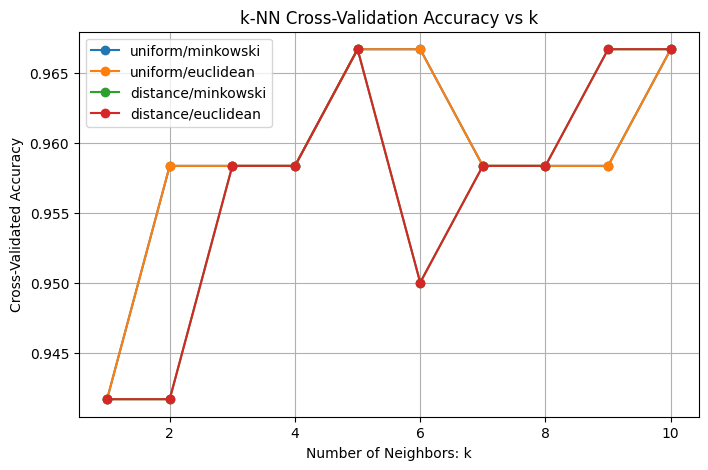

In [7]:
# Plot accuracy vs. k
plt.figure(figsize=(8, 5))
for (w, m), scores in cv_results.items():
    plt.plot(k_range, cv_results[(w, m)], marker='o', label=f'{w}/{m}')
plt.title("k-NN Cross-Validation Accuracy vs k")
plt.xlabel("Number of Neighbors: k")
plt.ylabel("Cross-Validated Accuracy")
plt.grid(True)
plt.legend()
plt.show()

The default values, k = 5 and the Euclidean distance metric, performed best for this model. Differences observed in cross-validation accuracy are likely due to overfitting in some configurations and the relatively small sample size of the dataset, where a single misclassification can produce a noticeable change in accuracy.

In [8]:
petal_fit = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski', p=2)
petal_fit.fit(X_petal_train_std, y_train)
petal_pred = petal_fit.predict(X_petal_test_std)
print("Classification Report:\n", classification_report(y_test, petal_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, petal_pred))
print("Accuracy Score:", accuracy_score(y_test, petal_pred))

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Accuracy Score: 0.9666666666666667


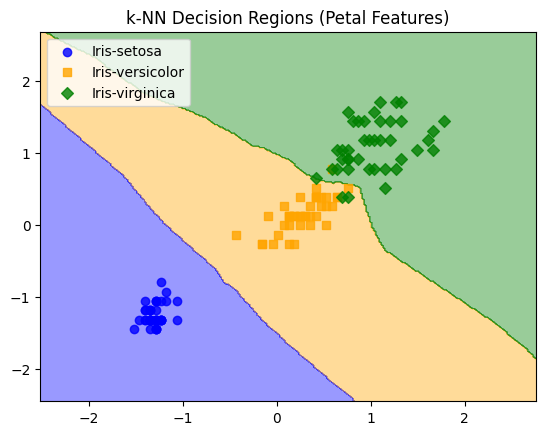

In [13]:
plot_decision_regions(X_petal_train_std, y_train, petal_fit, title="k-NN Decision Regions (Petal Features)")

In [14]:
sepal_fit = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski', p=2)
sepal_fit.fit(X_sepal_train_std, y_train)

sepal_pred = sepal_fit.predict(X_sepal_test_std)
print("Classification Report:\n", classification_report(y_test, sepal_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, sepal_pred))
print("Accuracy Score:", accuracy_score(y_test, sepal_pred))

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.55      0.60      0.57        10
 Iris-virginica       0.56      0.50      0.53        10

       accuracy                           0.70        30
      macro avg       0.70      0.70      0.70        30
   weighted avg       0.70      0.70      0.70        30

Confusion Matrix:
 [[10  0  0]
 [ 0  6  4]
 [ 0  5  5]]
Accuracy Score: 0.7


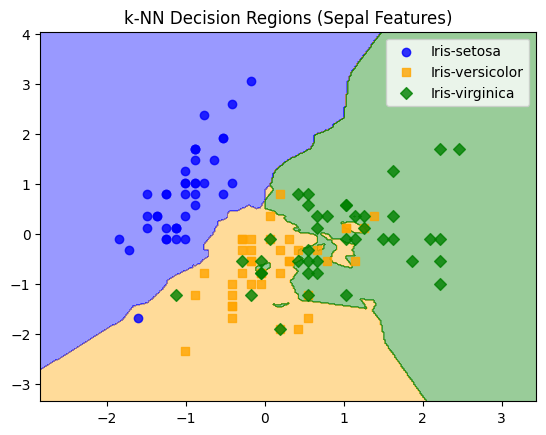

In [15]:
plot_decision_regions(X_sepal_train_std, y_train, sepal_fit, title="k-NN Decision Regions (Sepal Features)")

# Conclusion

k-Nearest Neighbors did not perform as well as the other classifiers, producing the lowest performance with two misclassifications in the best tuned model. In the two-feature visualization models, however, k-NN performed similarly to the other methods. Cross-validation showed that the default settings (k = 5 with Euclidean distance) worked best for the full four-feature model.